# Retrievers for RAG

#### What are Retrievers
A Retreiver is a component in LangChain that fetches relevnat documents from a data source in response to a users query

- All Retreivers are Runnables
- There are multiple types of Retreivers

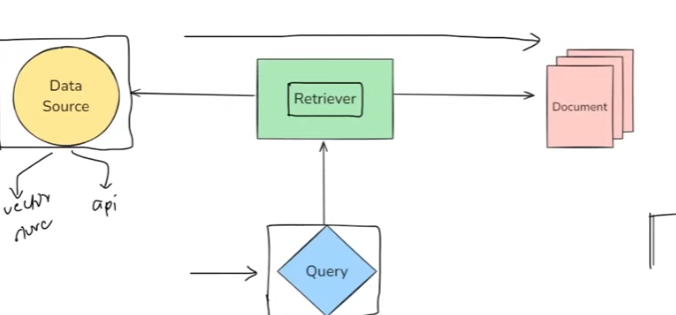

### Types of Retrievers

### Categorries based on data sources
- Wikipeda R
- Vector R
- Archive R etc

### Categories based on Search Strategy
- MMR 
- MultiQuery R
- Contextual compression etc

## Wikipedia Retriever

- A wikipedia R is a R that queries the wikipedia API to fetch relevant content for a given query

#### how it works:
- You give it a query
- It send the query to wikipedia API
- Retreives most relevant articles
- It return them as LangChain Document Objects

In [1]:
from langchain_community.retrievers import WikipediaRetriever

In [2]:
retriever = WikipediaRetriever(top_k_results = 2, lang = 'en')

In [3]:
query = "the geopolitical history of India and Pakistan from the perspective of china"

docs = retriever.invoke(query)

In [4]:
docs

[Document(metadata={'title': 'India–Pakistan war of 1971', 'summary': "The India–Pakistan war of 1971, also known as the third Indo-Pakistani war, was a military confrontation between India and Pakistan that occurred during the Bangladesh Liberation War in East Pakistan from 3 December 1971 until the Pakistani capitulation in Dhaka on 16 December 1971.  The war began with Pakistan's Operation Chengiz Khan, consisting of preemptive aerial strikes on eight Indian air stations. The strikes led to India declaring war on Pakistan, marking their entry into the war for East Pakistan's independence, on the side of Bengali nationalist forces. India's entry expanded the existing conflict with Indian and Pakistani forces engaging on both the eastern and western fronts.\nThirteen days after the war started, India achieved a clear upper hand, and the Eastern Command of the Pakistan military signed the instrument of surrender on 16 December 1971 in Dhaka, marking the formation of East Pakistan as th

In [7]:
for i, doc in enumerate(docs):
    print(f"\n--- Result {i + 1}---")
    print(f"content : \n {doc.page_content} ---")


--- Result 1---
content : 
 The India–Pakistan war of 1971, also known as the third Indo-Pakistani war, was a military confrontation between India and Pakistan that occurred during the Bangladesh Liberation War in East Pakistan from 3 December 1971 until the Pakistani capitulation in Dhaka on 16 December 1971.  The war began with Pakistan's Operation Chengiz Khan, consisting of preemptive aerial strikes on eight Indian air stations. The strikes led to India declaring war on Pakistan, marking their entry into the war for East Pakistan's independence, on the side of Bengali nationalist forces. India's entry expanded the existing conflict with Indian and Pakistani forces engaging on both the eastern and western fronts.
Thirteen days after the war started, India achieved a clear upper hand, and the Eastern Command of the Pakistan military signed the instrument of surrender on 16 December 1971 in Dhaka, marking the formation of East Pakistan as the new nation of Bangladesh. Approximately 9

# Vector Store Retriever

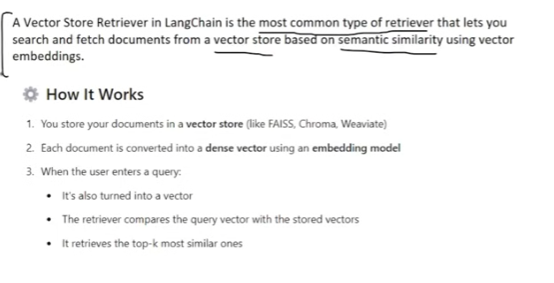

In [10]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from dotenv import load_dotenv 
from langchain_core.documents import Document

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
)

documents = [
    Document(page_content="Langchain helps developers build LLM applications easily"),
    Document(page_content="Chroma is vector databases optimised for LLMbased search"),
    Document(page_content="Embeddngs convert etxt into high-dimentional vectors"),
    Document(page_content="OpenAI provides powerful embedding models"),
]

embeddings_model = embeddings

vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embeddings_model,
    collection_name='MyAss'
    
)

c:\Users\HP\Documents\Coding journeys\GenAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5293.96it/s]


In [11]:
retriever = vectorstore.as_retriever(search_kwargs = {"k":2})

In [12]:
query = "what is chroma used for"
results = retriever.invoke(query)

for i, doc in enumerate(results):
    print(f"\n--- Result {i + 1}---")
    print(f"content : \n {doc.page_content} ---")


--- Result 1---
content : 
 Chroma is vector databases optimised for LLMbased search ---

--- Result 2---
content : 
 Langchain helps developers build LLM applications easily ---


# MMR - Maximum Marginal Relevance

MMR is an information retrieval algo designed to reduce redundancy in the retreived results while maintaining high relevanve to the query

like it wont bring the 3 papers that are too similar to each other it will bring related docs to query but dissimilar in themselves

In [13]:
docs = [
    Document(page_content = "LangChain makes it easy to work with LLMs"),
    Document(page_content = "LangChain is used to build LLMs based applications"),
    Document(page_content = "Chroma is used to store and search document embeddings"),
    Document(page_content = "Embedding are vector representations of text data"),
    Document(page_content = "MMR helps you get more diverse results from your retriever"),
    Document(page_content = "LangChain supports chroma, FAISS, pinecone and more vector databases"),
]

In [17]:
from langchain_community.vectorstores import FAISS

embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectorstore = FAISS.from_documents(docs, embedding_model)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8846.75it/s]


In [24]:
retriever = vectorstore.as_retriever(
    search_type = "mmr",
    search_kwargs = {"k":3, "lambda_mult": 0.5}
)

In [25]:
query = "what is chroma used for"
results = retriever.invoke(query)

In [26]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i + 1}---")
    print(f"content : \n {doc.page_content} ---")


--- Result 1---
content : 
 Chroma is used to store and search document embeddings ---

--- Result 2---
content : 
 LangChain makes it easy to work with LLMs ---

--- Result 3---
content : 
 LangChain supports chroma, FAISS, pinecone and more vector databases ---


# Multi Query Retriever

- sometimes a single query might not capture all the ways information in phrased in your document

- Like : how can be healthy? This is a ambigous question, we can answer in way too many context this retreiver solve this prolbem 

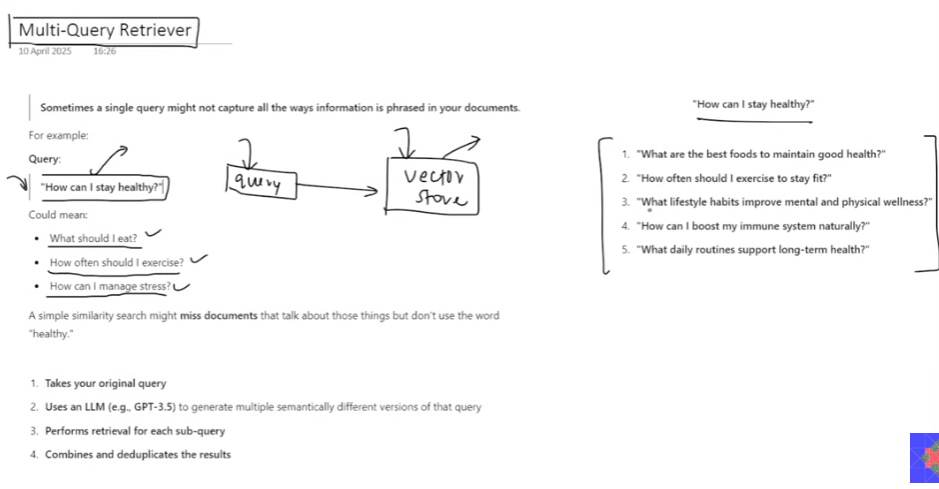

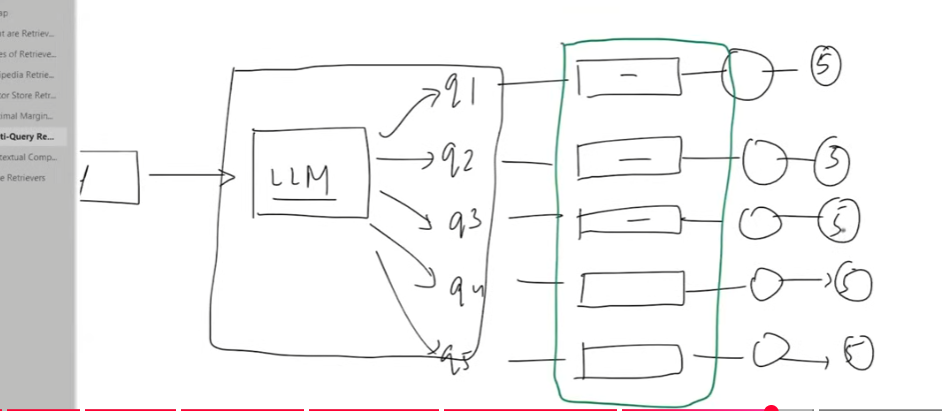

like this it generates multiple wuestion related to query using LLM and gets the response for each query and gives the best 

# Contextual Compression Retriever

- The contextual Compression Retreiver in langchain is an advances that improves retreival qulity by compressing documents after retrival - keeping only the relevant content based on the users query

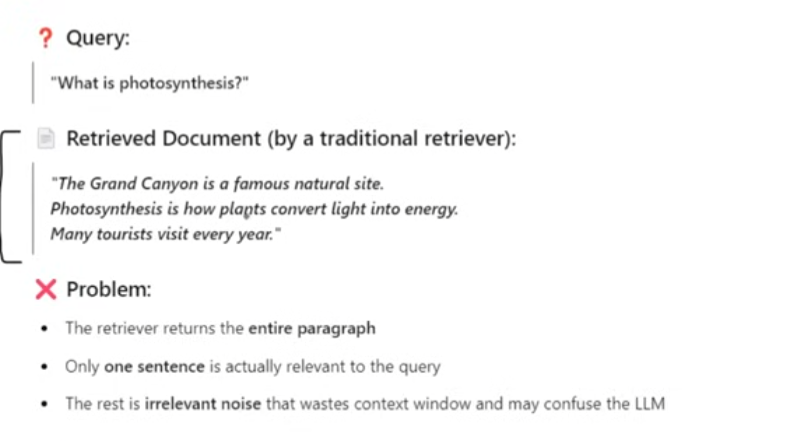

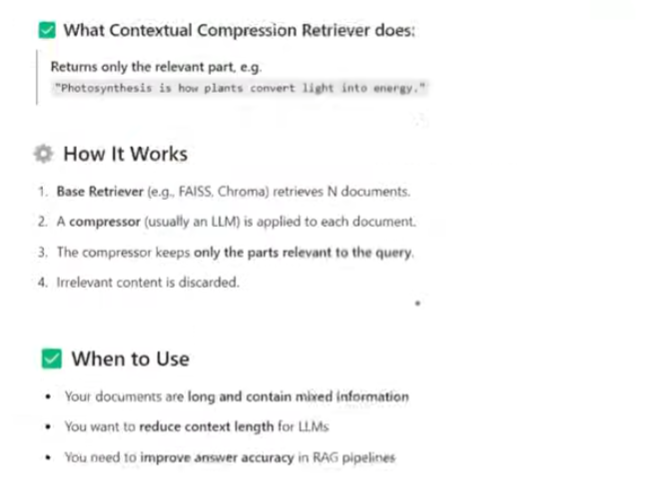

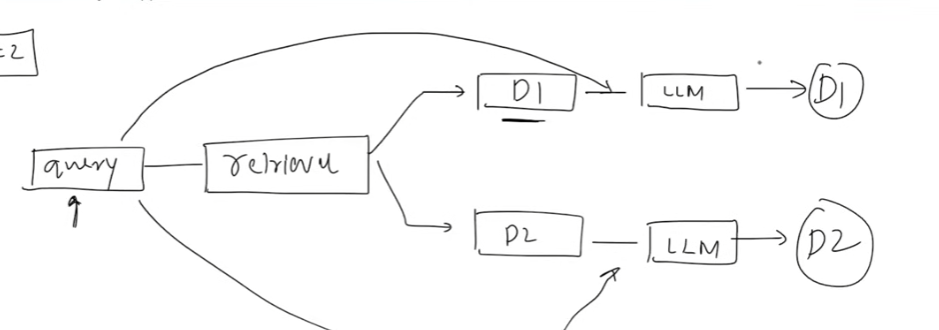

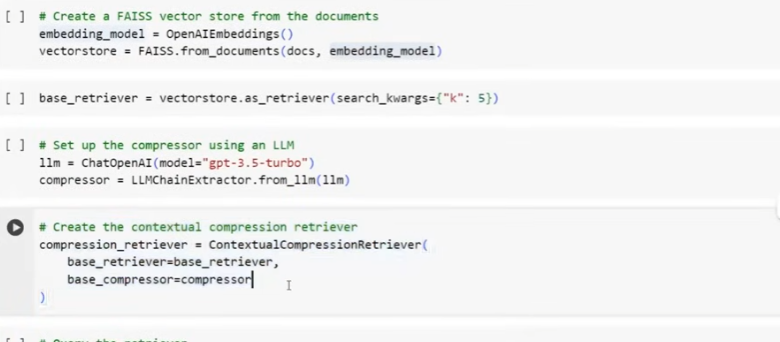

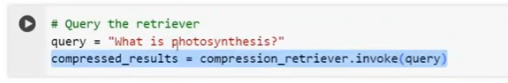